## 1. Project Introduction

## Predicting Cardiovascular Disease Risk Using Machine Learning and Healthcare Analytics

### A Comparative Study of Patient Health Indicators for Early Disease Detection

## Problem Statement

Cardiovascular disease remains one of the leading causes of death worldwide. Healthcare organizations collect large volumes of patient demographic, lifestyle, and clinical data, yet identifying individuals at high risk remains challenging. Traditional manual assessment may not fully leverage the predictive potential of these data. This project applies healthcare analytics and machine learning techniques to analyze patient characteristics, identify key cardiovascular risk factors, and develop predictive models that support earlier risk detection and informed clinical decision-making 

##  Research Objectives

The objectives of this project are:

1. **To identify** the demographic, lifestyle, and clinical factors that are most strongly associated with the occurrence of cardiovascular disease.

2. **To calculate** Body Mass Index (BMI) using patients' height and weight measurements and evaluate its relationship with the prevalence of cardiovascular disease.

3. **To examine** whether demographic characteristics, including gender, country, and occupation, are associated with cardiovascular disease risk.

4. **To develop and compare** multiple machine learning classification models for predicting cardiovascular disease risk and identify the best-performing model based on evaluation metrics.

   **Machine Learning Models**
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - XGBoost *(optional)*


5. **To evaluate** the influence of lifestyle factors, including physical activity, smoking, and alcohol consumption, on the likelihood of developing cardiovascular disease.


## 2 Import Basic Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3 Load the Dataset

In [2]:
df = pd.read_csv('cardio_data_clean.csv') 

# Ensuring the Correct Data Was Loaded from SQL
Objective: 

To verify that the cleaned dataset exported from SQL Server has been successfully imported into Python before performing exploratory data analysis and machine learning.

In [3]:
print(df.columns)
print(df.shape)

Index(['date', 'country', 'id', 'active', 'age', 'alco', 'ap_hi', 'ap_lo',
       'cholesterol', 'gender', 'gluc', 'height', 'occupation', 'smoke',
       'weight', 'disease', 'Valid_BP'],
      dtype='object')
(68370, 17)


In [4]:
df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease,Valid_BP
0,00:00.0,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62,0,Valid
1,00:00.0,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85,1,Valid
2,00:00.0,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64,1,Valid
3,00:00.0,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82,1,Valid
4,00:00.0,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56,0,Valid


## 4. Data Inspection

In [5]:
# Display all columns
df.info

<bound method DataFrame.info of           date    country     id  active    age  alco  ap_hi  ap_lo  \
0      00:00.0  Indonesia      0       1  18393     0    110     80   
1      00:00.0   Malaysia      1       1  20228     0    140     90   
2      00:00.0  Indonesia      2       0  18857     0    130     70   
3      00:00.0  Singapore      3       1  17623     0    150    100   
4      00:00.0  Singapore      4       0  17474     0    100     60   
...        ...        ...    ...     ...    ...   ...    ...    ...   
68365  00:00.0  Singapore  99993       1  19240     0    120     80   
68366  00:00.0   Malaysia  99995       1  22601     0    140     90   
68367  00:00.0   Malaysia  99996       0  19066     1    180     90   
68368  00:00.0  Singapore  99998       0  22431     0    135     80   
68369  00:00.0  Singapore  99999       1  20540     0    120     80   

       cholesterol  gender  gluc  height  occupation  smoke  weight  disease  \
0                1       2     1   

In [6]:
#Check all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68370 entries, 0 to 68369
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         68370 non-null  object
 1   country      68370 non-null  object
 2   id           68370 non-null  int64 
 3   active       68370 non-null  int64 
 4   age          68370 non-null  int64 
 5   alco         68370 non-null  int64 
 6   ap_hi        68370 non-null  int64 
 7   ap_lo        68370 non-null  int64 
 8   cholesterol  68370 non-null  int64 
 9   gender       68370 non-null  int64 
 10  gluc         68370 non-null  int64 
 11  height       68370 non-null  int64 
 12  occupation   68370 non-null  object
 13  smoke        68370 non-null  int64 
 14  weight       68370 non-null  int64 
 15  disease      68370 non-null  int64 
 16  Valid_BP     68370 non-null  object
dtypes: int64(13), object(4)
memory usage: 8.9+ MB


In [7]:
# Checking of numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Variables:")
print(numerical_cols)

print("\nCategorical Variables:")
print(categorical_cols)

Numerical Variables:
Index(['id', 'active', 'age', 'alco', 'ap_hi', 'ap_lo', 'cholesterol',
       'gender', 'gluc', 'height', 'smoke', 'weight', 'disease'],
      dtype='object')

Categorical Variables:
Index(['date', 'country', 'occupation', 'Valid_BP'], dtype='object')


In [8]:
# No of Numerical/Categorical Columns
print(f"Number of Numerical Variables: {len(numerical_cols)}")
print(f"Number of Categorical Variables: {len(categorical_cols)}")

Number of Numerical Variables: 13
Number of Categorical Variables: 4


##  Gender Analysis

Objective:
To determine whether gender is associated with cardiovascular disease prevalence.

In [9]:
df.dtypes

date           object
country        object
id              int64
active          int64
age             int64
alco            int64
ap_hi           int64
ap_lo           int64
cholesterol     int64
gender          int64
gluc            int64
height          int64
occupation     object
smoke           int64
weight          int64
disease         int64
Valid_BP       object
dtype: object

In [10]:
# Ascertaning the number of patients per gender.
gender_summary = df.groupby("gender").agg({
    "disease": ["count", "sum"]
})

gender_summary.columns = ["Total_Patients", "Patients_With_Disease"]

gender_summary["Disease_Rate"] = (
    gender_summary["Patients_With_Disease"]
    / gender_summary["Total_Patients"]
    * 100
)

print(gender_summary)

        Total_Patients  Patients_With_Disease  Disease_Rate
gender                                                     
1                44497                  21905     49.228038
2                23873                  11927     49.960206


In [12]:
#Assigning gender to numeric codes
gender_summary = gender_summary.reset_index()

gender_summary["gender"] = gender_summary["gender"].replace({
    1: "Female",
    2: "Male"
})

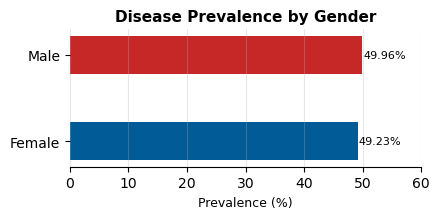

In [13]:
#Plotting the graph

# Smaller figure for PowerPoint
plt.figure(figsize=(4.5, 2.3))

colors = ['#005B96', '#C62828']

bars = plt.barh(
    gender_summary["gender"],
    gender_summary["Disease_Rate"],
    color=colors,
    height=0.45
)

plt.title("Disease Prevalence by Gender", fontsize=11, weight='bold')
plt.xlabel("Prevalence (%)", fontsize=9)

# Remove unnecessary labels
plt.ylabel("")

# Add values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.15,
             bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%",
             va='center',
             fontsize=8)

# Keep the scale honest
plt.xlim(0, 60)

# Remove clutter
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

# How did you know Gender 2 was male?

Before any data transformation, I investigated the coded variables. I grouped patients by gender and compared their average height and smoking prevalence. One group averaged approximately 161 cm with a 2% smoking rate, while the other averaged approximately 170 cm with a 21% smoking rate. Based on these observed characteristics, I inferred the coding before proceeding with further analysis.

# Occupation Analysis

In [14]:
print(df["occupation"].value_counts().sort_index())

occupation
Accountant    7685
Architect     7675
Chef          7545
Doctor        7526
Engineer      7501
Lawyer        7551
Nurse         7741
Others        7636
Teacher       7510
Name: count, dtype: int64


In [15]:
#Occupation grouping
occupation_summary = df.groupby("occupation").agg({
    "disease": ["count", "sum"]
})

occupation_summary.columns = ["Total_Patients", "Patients_With_Disease"]

occupation_summary["Disease_Rate"] = (
    occupation_summary["Patients_With_Disease"]
    / occupation_summary["Total_Patients"]
    * 100
)

occupation_summary = occupation_summary.sort_values(
    by="Disease_Rate",
    ascending=False
)

occupation_summary

,Total_Patients,Patients_With_Disease,Disease_Rate
occupation,,,
Accountant,7685,3878,50.461939
Teacher,7510,3750,49.933422
Lawyer,7551,3745,49.596080
Others,7636,3785,49.567837
Architect,7675,3791,49.394137
Nurse,7741,3822,49.373466
Doctor,7526,3708,49.269200
Chef,7545,3696,48.986083
Engineer,7501,3657,48.753500


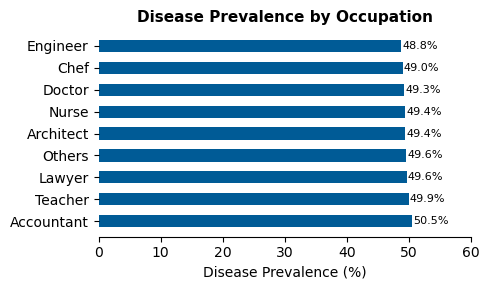

In [16]:
occupation_summary = occupation_summary.reset_index()

plt.figure(figsize=(5,3))

bars = plt.barh(
    occupation_summary["occupation"],
    occupation_summary["Disease_Rate"],
    color="#005B96",
    height=0.55
)

plt.title("Disease Prevalence by Occupation",
          fontsize=11,
          weight="bold")

plt.xlabel("Disease Prevalence (%)")
plt.ylabel("")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2,
             bar.get_y() + bar.get_height()/2,
             f"{width:.1f}%",
             va="center",
             fontsize=8)

plt.xlim(0,60)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

# Inaccurate description

Above data of Numerical Variables and Categorical Variables is misleading. Example Male and Female is categorical column but is denoted as Numerical (int-64) as the numbers are indicated 1 for male and 2 for female. Similar issue for columns such as gender, cholesterol, smoke, and active as Numerical Variables even though they are conceptually Categorical.  

In [17]:
# List of columns that are actually categorical
categorical_columns = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'disease']

# Convert these columns to 'category' type
for col in categorical_columns:
    df[col] = df[col].astype('category')

# Run check again
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Revised Categorical Variables:", categorical_cols)
print("Numerical Variables:", numerical_cols)

Revised Categorical Variables: Index(['date', 'country', 'active', 'alco', 'cholesterol', 'gender', 'gluc',
       'occupation', 'smoke', 'disease', 'Valid_BP'],
      dtype='object')
Numerical Variables: Index(['id', 'age', 'ap_hi', 'ap_lo', 'height', 'weight'], dtype='object')


In [18]:
# No of Revised Numerical/Categorical Columns
print(f"Number of Numerical Variables: {len(numerical_cols)}")
print(f"Number of Categorical Variables: {len(categorical_cols)}")

Number of Numerical Variables: 6
Number of Categorical Variables: 11


In [19]:
df.describe(include='all').head(3)

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease,Valid_BP
count,68370,68370,68370.0,68370.0,68370.0,68370.0,68370.0,68370.0,68370.0,68370.0,68370.0,68370.0,68370,68370.0,68370.0,68370.0,68370
unique,1,4,NaN,2.0,NaN,2.0,NaN,NaN,3.0,2.0,3.0,NaN,9,2.0,NaN,2.0,1
top,00:00.0,Singapore,NaN,1.0,NaN,0.0,NaN,NaN,1.0,1.0,1.0,NaN,Nurse,0.0,NaN,0.0,Valid


In [20]:
# Checking for Null values
df.isnull().sum()

date           0
country        0
id             0
active         0
age            0
alco           0
ap_hi          0
ap_lo          0
cholesterol    0
gender         0
gluc           0
height         0
occupation     0
smoke          0
weight         0
disease        0
Valid_BP       0
dtype: int64

# 5. Exploratory Data Analysis (EDA)

## 5.1 Distribution of Demographic Variables

## Objective

The objective of this analysis is to examine the distributions of the demographic variables (age, height, and weight) after data cleaning. Understanding these distributions helps verify data quality, identify potential outliers, and determine whether additional feature engineering is required before developing machine learning models.

## Methodology

Histograms were generated using Matplotlib to visualize the frequency distributions of the three numerical variables:

Age – to understand the age profile of the study population.
Height – to verify realistic human height measurements after data cleaning.
Weight – to assess the spread of body weight and identify potential skewness.

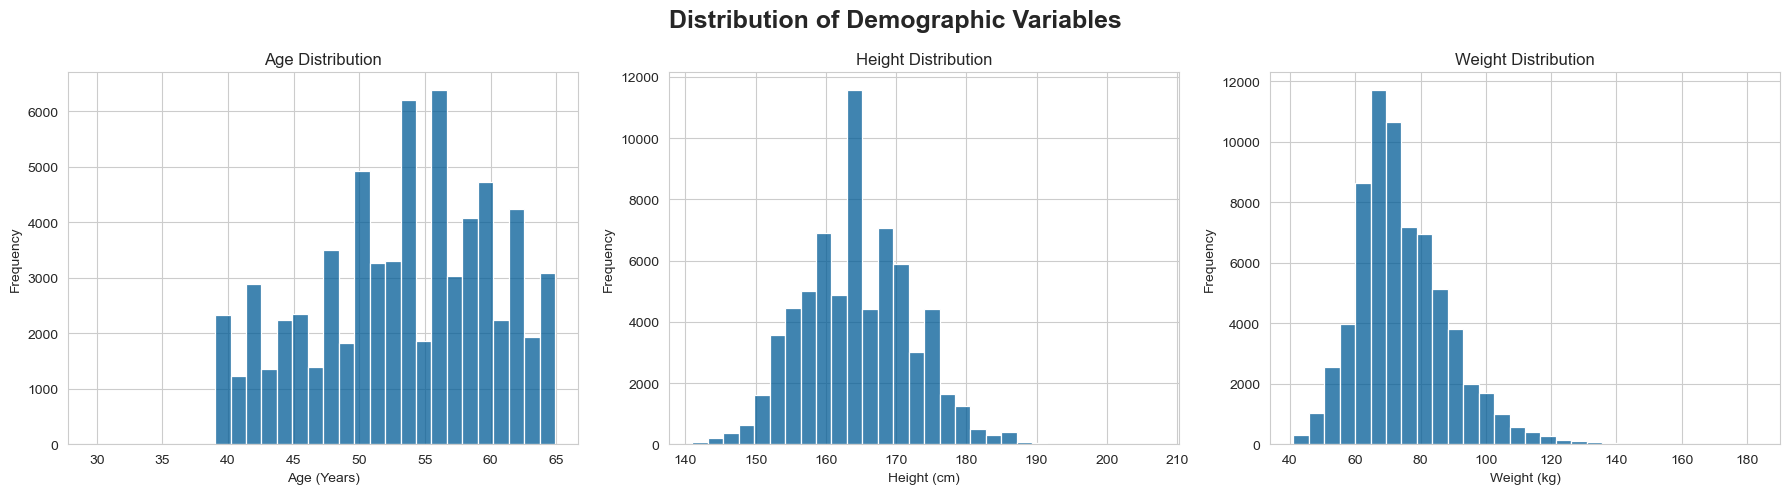

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Age in Years
df['Age_Years'] = (df['age'] / 365.25).round(1)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Age
sns.histplot(
    data=df,
    x='Age_Years',
    bins=30,
    color='#005B96',
    edgecolor='white',
    ax=axes[0]
)

axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Frequency')

# Height
sns.histplot(
    data=df,
    x='height',
    bins=30,
    color='#005B96',
    edgecolor='white',
    ax=axes[1]
)

axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (cm)')
axes[1].set_ylabel('Frequency')

# Weight
sns.histplot(
    data=df,
    x='weight',
    bins=30,
    color='#005B96',
    edgecolor='white',
    ax=axes[2]
)

axes[2].set_title('Weight Distribution')
axes[2].set_xlabel('Weight (kg)')
axes[2].set_ylabel('Frequency')

plt.suptitle(
    'Distribution of Demographic Variables',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Observations

Age

Most patients are between 50 and 60 years old.
Very few patients are younger than 40 or older than 65.
This reflects the age group in which cardiovascular disease is more commonly observed.

Height

Height follows an approximately normal distribution centred around 165–170 cm.
No obvious unrealistic values remain after preprocessing, indicating successful data cleaning.

Weight

Weight displays a slight right-skewed distribution.
Most patients weigh between 60 and 80 kg, with a smaller proportion of heavier patients extending beyond 100 kg.

# Distribution of Clinical Variables

# Objective

To examine the distributions of systolic blood pressure, diastolic blood pressure, cholesterol, and glucose after data cleaning and assess whether these clinical variables exhibit realistic patterns suitable for predictive modelling.

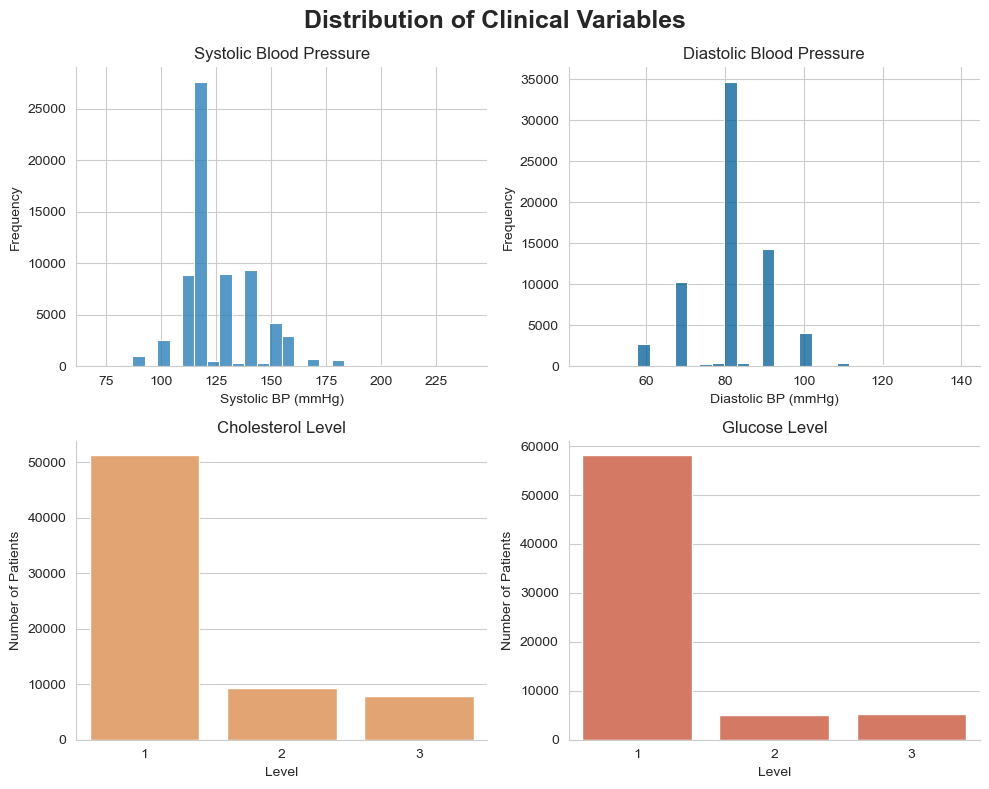

In [22]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# -----------------------------
# Systolic Blood Pressure
# -----------------------------
sns.histplot(
    data=df,
    x='ap_hi',
    bins=30,
    color='#1F77B4',
    edgecolor='white',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Systolic Blood Pressure')
axes[0, 0].set_xlabel('Systolic BP (mmHg)')
axes[0, 0].set_ylabel('Frequency')

# -----------------------------
# Diastolic Blood Pressure
# -----------------------------
sns.histplot(
    data=df,
    x='ap_lo',
    bins=30,
    color='#005B96',
    edgecolor='white',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Diastolic Blood Pressure')
axes[0, 1].set_xlabel('Diastolic BP (mmHg)')
axes[0, 1].set_ylabel('Frequency')

# -----------------------------
# Cholesterol
# -----------------------------
sns.countplot(
    data=df,
    x='cholesterol',
    color='#F4A261',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Cholesterol Level')
axes[1, 0].set_xlabel('Level')
axes[1, 0].set_ylabel('Number of Patients')

# -----------------------------
# Glucose
# -----------------------------
sns.countplot(
    data=df,
    x='gluc',
    color='#E76F51',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Glucose Level')
axes[1, 1].set_xlabel('Level')
axes[1, 1].set_ylabel('Number of Patients')

plt.suptitle(
    'Distribution of Clinical Variables',
    fontsize=18,
    fontweight='bold'
)

sns.despine()
plt.tight_layout()
plt.show()

## Observations

Systolic Blood Pressure (ap_hi)

Most readings fall between 110 and 140 mmHg.
The distribution is centred around clinically expected values, with no obvious unrealistic outliers.

Diastolic Blood Pressure (ap_lo)

Most readings are between 70 and 90 mmHg.
The data appears clinically plausible following SQL-based cleaning.

Cholesterol

Level 1 is the dominant category.
Levels 2 and 3 represent smaller groups with elevated cholesterol that may indicate increased cardiovascular risk.

Glucose

Most patients belong to Level 1.
Elevated glucose levels (Levels 2 and 3) occur less frequently but identify higher-risk patients.

# Correlation Heatmap of Clinical Variables

## Objective

To examine the relationships between numerical variables and identify those most strongly associated with cardiovascular disease.

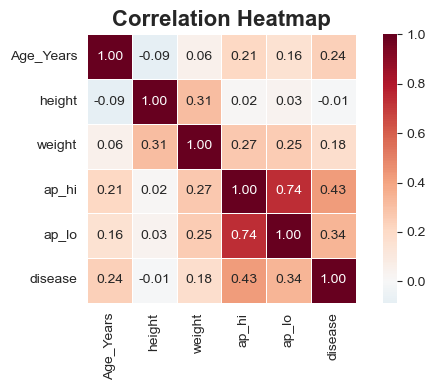

In [23]:
# Create Age in Years
df['Age_Years'] = (df['age'] / 365.25).round(1)

# Select numerical variables
corr_df = df[['Age_Years',
              'height',
              'weight',
              'ap_hi',
              'ap_lo',
              'disease']]

# Calculate correlation matrix
corr_matrix = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Observations

Systolic and diastolic blood pressure exhibit the strongest positive correlation (r = 0.74), reflecting their close physiological relationship.
Cardiovascular disease shows its strongest association with:
Systolic blood pressure (r = 0.43)
Diastolic blood pressure (r = 0.34)
Age (r = 0.24)
Weight demonstrates a relatively weak positive correlation with disease (r = 0.18).
Height has virtually no correlation with disease (r = -0.01).

# Disease Distribution by Age

A boxplot was used to compare the age distributions of patients with and without cardiovascular disease.

<Axes: xlabel='disease', ylabel='Age_Years'>

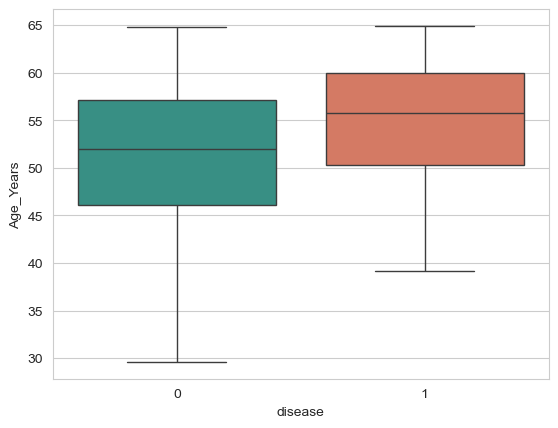

In [24]:
sns.boxplot(
    data=df,
    x='disease',
    y='Age_Years',
    hue='disease',
    palette=['#2A9D8F', '#E76F51'],
    legend=False
)

**Observations**

- Patients with cardiovascular disease exhibited a higher median age than patients without disease.
- The disease group showed an upward shift in the interquartile range, indicating that older ages were more common.
- Some overlap existed between the two groups, suggesting that age alone is insufficient to distinguish disease status.
- Several outliers were present in both groups but did not affect the overall trend.

**Business Insight**

Age demonstrates a positive association with cardiovascular disease. Although it is not a standalone predictor, the observed age differences support its inclusion as an important feature in the predictive machine learning models.

# Blood Pressure Distribution by Cardiovascular Disease

This analysis compares systolic and diastolic blood pressure between patients with and without cardiovascular disease.


C:\Users\Christopher\AppData\Local\Temp\ipykernel_7152\2423287573.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Disease', 'Disease'])
C:\Users\Christopher\AppData\Local\Temp\ipykernel_7152\2423287573.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Disease', 'Disease'])


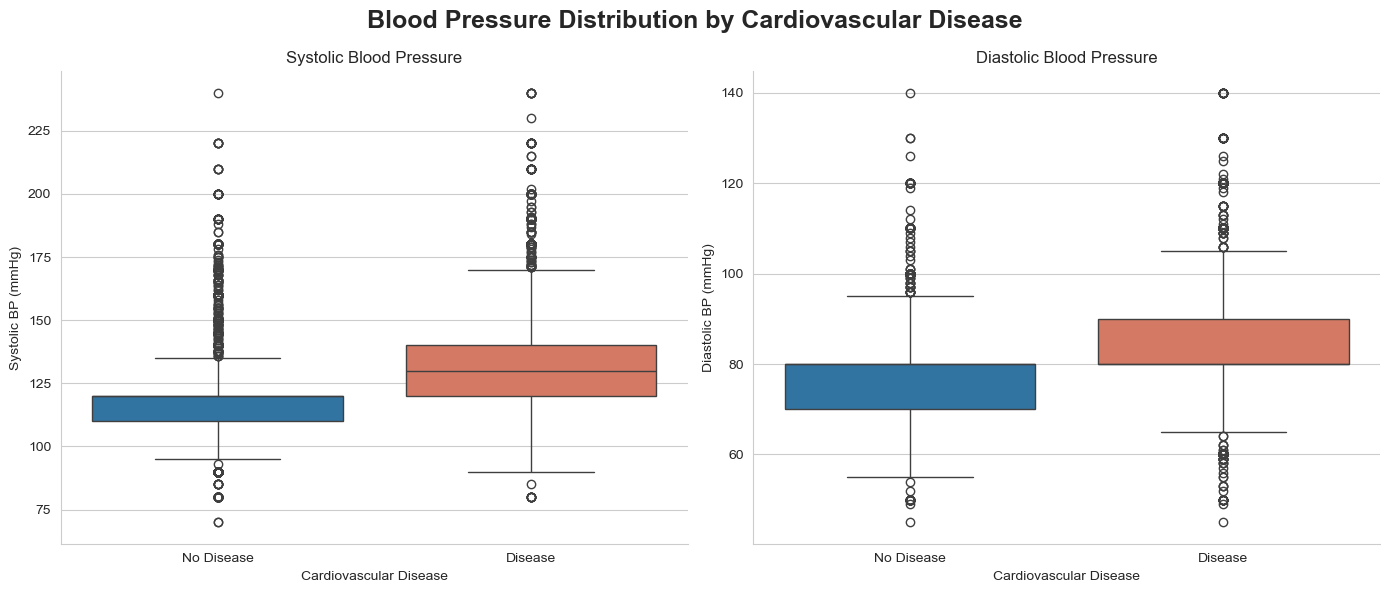

In [25]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Systolic Blood Pressure
sns.boxplot(
    data=df,
    x='disease',
    y='ap_hi',
    hue='disease',
    palette=['#1F77B4', '#E76F51'],
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Systolic Blood Pressure')
axes[0].set_xlabel('Cardiovascular Disease')
axes[0].set_ylabel('Systolic BP (mmHg)')
axes[0].set_xticklabels(['No Disease', 'Disease'])

# Diastolic Blood Pressure
sns.boxplot(
    data=df,
    x='disease',
    y='ap_lo',
    hue='disease',
    palette=['#1F77B4', '#E76F51'],
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Diastolic Blood Pressure')
axes[1].set_xlabel('Cardiovascular Disease')
axes[1].set_ylabel('Diastolic BP (mmHg)')
axes[1].set_xticklabels(['No Disease', 'Disease'])

plt.suptitle(
    'Blood Pressure Distribution by Cardiovascular Disease',
    fontsize=18,
    fontweight='bold'
)

sns.despine()
plt.tight_layout()
plt.show()

### Observations
- Patients with cardiovascular disease have higher median systolic and diastolic blood pressure.
- Blood pressure distributions for the disease group are shifted toward higher values.
- Some overlap exists between groups, indicating that blood pressure alone does not completely determine disease status.
- Elevated blood pressure appears to be strongly associated with cardiovascular disease.

### Interpretation
The boxplots suggest that both systolic and diastolic blood pressure are important clinical predictors of cardiovascular disease. These findings are consistent with the earlier SQL analysis and support including blood pressure variables in subsequent machine learning models.

# Lifestyle Factors and Cardiovascular Disease

This analysis examines whether smoking, alcohol consumption and physical activity are associated with cardiovascular disease.


C:\Users\Christopher\AppData\Local\Temp\ipykernel_7152\805075238.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Smoker', 'Smoker'])
C:\Users\Christopher\AppData\Local\Temp\ipykernel_7152\805075238.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Yes'])
C:\Users\Christopher\AppData\Local\Temp\ipykernel_7152\805075238.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['No', 'Yes'])


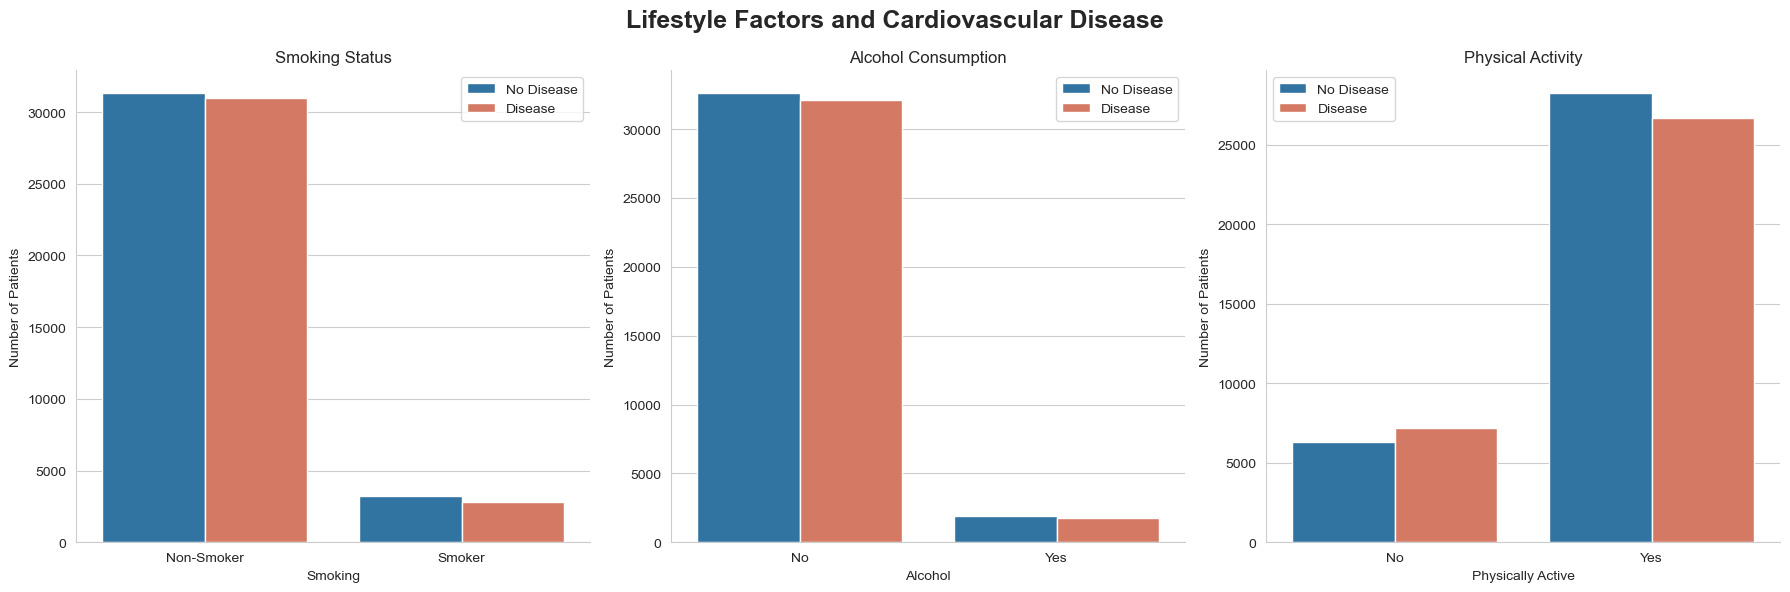

In [26]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Smoking
sns.countplot(
    data=df,
    x='smoke',
    hue='disease',
    palette=['#1F77B4', '#E76F51'],
    ax=axes[0]
)
axes[0].set_title('Smoking Status')
axes[0].set_xlabel('Smoking')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticklabels(['Non-Smoker', 'Smoker'])
axes[0].legend(['No Disease', 'Disease'])

# Alcohol
sns.countplot(
    data=df,
    x='alco',
    hue='disease',
    palette=['#1F77B4', '#E76F51'],
    ax=axes[1]
)
axes[1].set_title('Alcohol Consumption')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Number of Patients')
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].legend(['No Disease', 'Disease'])

# Physical Activity
sns.countplot(
    data=df,
    x='active',
    hue='disease',
    palette=['#1F77B4', '#E76F51'],
    ax=axes[2]
)
axes[2].set_title('Physical Activity')
axes[2].set_xlabel('Physically Active')
axes[2].set_ylabel('Number of Patients')
axes[2].set_xticklabels(['No', 'Yes'])
axes[2].legend(['No Disease', 'Disease'])

plt.suptitle(
    'Lifestyle Factors and Cardiovascular Disease',
    fontsize=18,
    fontweight='bold'
)

sns.despine()
plt.tight_layout()
plt.show()

### Observations
- Physically inactive patients exhibit a higher prevalence of cardiovascular disease.
- Smoking shows a modest association with disease prevalence.
- Alcohol consumption alone demonstrates a relatively weak relationship with cardiovascular disease.
- Lifestyle factors contribute to disease risk but appear more informative when analysed together.

### Interpretation
Lifestyle behaviours influence cardiovascular disease risk, particularly physical inactivity. Although their effects are generally weaker than clinical measurements, these variables provide complementary information and will be retained as predictors for the machine learning models.

# 6. Feature Engineering – Body Mass Index (BMI)

Following exploratory data analysis, a new Body Mass Index (BMI) feature was created from patients' height and weight measurements.

## BMI Formula

BMI = Weight (kg) / Height² (m²)

In [27]:
# Create BMI

df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)

# Round BMI to 2 decimal places
df['BMI'] = df['BMI'].round(2)

# Display first few records
df[['height', 'weight', 'BMI']].head()

,height,weight,BMI
0,168,62,21.97
1,156,85,34.93
2,165,64,23.51
3,169,82,28.71
4,156,56,23.01


In [28]:
#Statistics
df['BMI'].describe()

count    68370.000000
mean        27.441021
std          5.169873
min         14.530000
25%         23.880000
50%         26.350000
75%         30.120000
max         68.310000
Name: BMI, dtype: float64

In [29]:
# Checking for null
df['BMI'].isnull().sum()

np.int64(0)

## Feature Engineering Steps

- Converted height from centimetres to metres.
- Calculated BMI for every patient.
- Added BMI as a new feature to the dataset.
- Categorised BMI using standard clinical classifications.
- Evaluated the relationship between BMI and cardiovascular disease.

## Interpretation

BMI is a clinically recognised measure of obesity that combines height and weight into a single indicator. Compared with weight alone, BMI provides additional information regarding cardiovascular risk and is retained as a new feature for machine learning.

# BMI Distribution by Cardiovascular Disease

After completing the exploratory data analysis, a new feature, **Body Mass Index (BMI)**, was created using each patient's height and weight.

BMI provides a standardized measure of body composition and is more informative than weight alone because it accounts for differences in height.

The purpose of this analysis is to compare BMI distributions between patients with and without cardiovascular disease and determine whether BMI is a useful predictor for subsequent machine learning models.

BMI Formula:

\[
BMI = \frac{\text{Weight (kg)}}{\left(\text{Height (m)}\right)^2}
\]

A boxplot is used to compare the BMI distributions across disease groups by examining the median, spread (IQR), and presence of outliers.

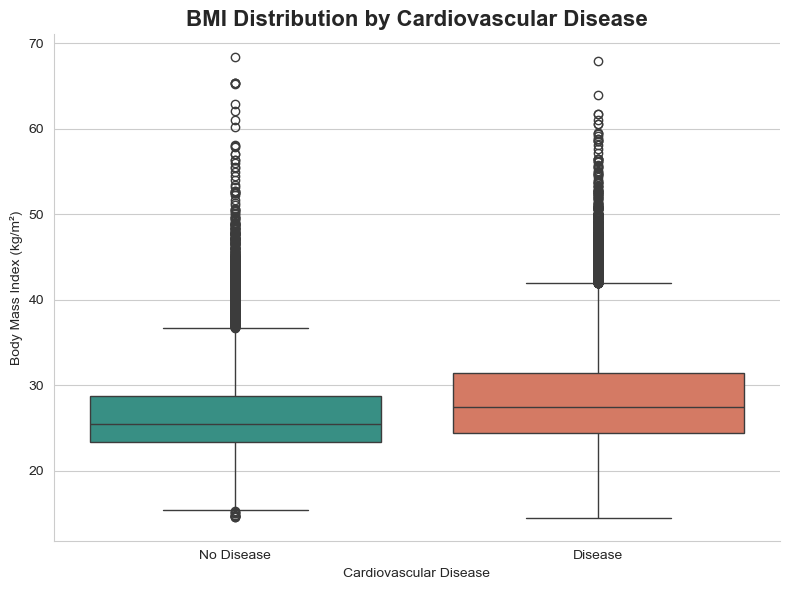

In [30]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='disease',
    y='BMI',
    hue='disease',
    palette=['#2A9D8F', '#E76F51'],
    legend=False
)

plt.title(
    'BMI Distribution by Cardiovascular Disease',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Cardiovascular Disease')
plt.ylabel('Body Mass Index (kg/m²)')

plt.xticks([0,1], ['No Disease', 'Disease'])

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The boxplot indicates that patients diagnosed with cardiovascular disease generally have higher BMI values than patients without disease.

The median BMI of the disease group is higher, suggesting an association between increased body mass and cardiovascular disease.

Although there is overlap between the two groups, the upward shift in BMI among diseased patients indicates that BMI provides useful predictive information while not being sufficient on its own to determine disease status.

These findings support the inclusion of BMI as an engineered feature for machine learning.

# 7. Machine Learning 

## Objective

To prepare the cleaned dataset for predictive modelling.

### Preparation Steps

- Selected the features identified during exploratory data analysis.
- Defined cardiovascular disease as the target variable.
- Split the dataset into training (80%) and testing (20%) subsets.
- Applied feature scaling to numerical variables where required.
- Prepared the data for Logistic Regression, Decision Tree and Random Forest classifiers.

The prepared dataset provides the foundation for building and evaluating predictive models capable of identifying patients at risk of cardiovascular disease.

In [31]:
from sklearn.model_selection import train_test_split

# Predictor variables
X = df[['Age_Years',
        'gender',
        'height',
        'weight',
        'BMI',
        'ap_hi',
        'ap_lo',
        'cholesterol',
        'gluc',
        'smoke',
        'alco',
        'active']]

# Target variable
y = df['disease']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (54696, 12)
Testing Set : (13674, 12)




## 7.1 Logistic Regression Model

### Objective

To develop a Logistic Regression model for predicting cardiovascular disease and evaluate its performance using standard classification metrics.

### Why Logistic Regression?

Logistic Regression was selected as the baseline classification model because it is widely used for binary classification problems. It estimates the probability of a patient having cardiovascular disease based on demographic, clinical, lifestyle, and engineered features. The model also provides an interpretable benchmark for comparison with more advanced machine learning algorithms.

### Input Features

- Age
- Gender
- Height
- Weight
- Body Mass Index (BMI)
- Systolic Blood Pressure
- Diastolic Blood Pressure
- Cholesterol
- Glucose
- Smoking Status
- Alcohol Consumption
- Physical Activity

### Target Variable

- **Disease**
  - 0 = No Cardiovascular Disease
  - 1 = Cardiovascular Disease

### Model Evaluation Metrics

The Logistic Regression model will be evaluated using the following performance metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics will be compared with the Decision Tree and Random Forest models to identify the most effective predictive model.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.7297791428989323


C:\Users\Christopher\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Generate All Evaluation Metrics

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Probability predictions (for ROC-AUC)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.7298
Precision: 0.7631
Recall   : 0.6651
F1-Score : 0.7107
ROC-AUC  : 0.7910

Confusion Matrix
[[5440 1409]
 [2286 4539]]

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.79      0.75      6849
           1       0.76      0.67      0.71      6825

    accuracy                           0.73     13674
   macro avg       0.73      0.73      0.73     13674
weighted avg       0.73      0.73      0.73     13674



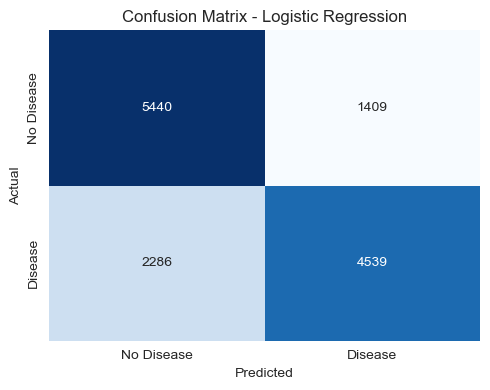

In [34]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## 7.2 Decision Tree Model

### Objective

To build a Decision Tree classifier for predicting cardiovascular disease and compare its performance against the Logistic Regression model.

### Why Decision Tree?

Decision Tree is a supervised machine learning algorithm that classifies data by creating a series of decision rules. It is easy to interpret, captures non-linear relationships between variables, and identifies the most important predictors influencing cardiovascular disease.

### Model Evaluation Metrics

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Probability predictions
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
roc_auc = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.6368
Precision: 0.6370
Recall   : 0.6330
F1-Score : 0.6350
ROC-AUC  : 0.6366

Confusion Matrix
[[4387 2462]
 [2505 4320]]

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.64      0.64      6849
           1       0.64      0.63      0.63      6825

    accuracy                           0.64     13674
   macro avg       0.64      0.64      0.64     13674
weighted avg       0.64      0.64      0.64     13674



## 7.3 Random Forest Model

### Objective

To develop a Random Forest classifier for predicting cardiovascular disease and compare its performance with Logistic Regression and Decision Tree models.

### Why Random Forest?

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve predictive performance. By aggregating the predictions of many trees, it reduces overfitting, increases model stability, and often achieves higher accuracy than a single Decision Tree.

### Model Evaluation Metrics

The Random Forest model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

The results will be compared with the Logistic Regression and Decision Tree models to identify the most effective predictive model.

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Metrics
print(f"Accuracy : {accuracy_score(y_test,y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred_rf):.4f}")
print(f"F1-Score : {f1_score(y_test,y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test,y_prob_rf):.4f}")

print(confusion_matrix(y_test,y_pred_rf))

Accuracy : 0.7105
Precision: 0.7184
Recall   : 0.6907
F1-Score : 0.7043
ROC-AUC  : 0.7710
[[5001 1848]
 [2111 4714]]


# Comparison of Machine Learning Models

## Objective

To compare the predictive performance of the three machine learning models and identify the most suitable classifier for cardiovascular disease prediction.

## Model Comparison

Three classification models were evaluated using the same training and testing datasets. Their performance was assessed using Accuracy, Precision, Recall, F1-Score, and ROC-AUC to ensure a consistent and fair comparison.

### Summary of Results

- Logistic Regression achieved the highest overall performance, recording the best Accuracy, Precision, F1-Score, and ROC-AUC.
- Random Forest achieved the highest Recall, indicating a greater ability to identify patients with cardiovascular disease.
- Decision Tree produced the weakest overall performance across the evaluation metrics.

## Conclusion

Based on the comparative analysis, Logistic Regression was selected as the preferred model because it demonstrated the best overall balance of predictive performance and generalisation. While Random Forest identified more positive disease cases, Logistic Regression provided the most reliable and consistent results for this dataset.

# 9. Recommendations

## Objective

To provide practical recommendations based on the findings from the exploratory data analysis and machine learning models.

## Recommendations

### Healthcare
- Prioritise cardiovascular screening for patients with elevated clinical risk factors.
- Promote healthy lifestyle interventions, including physical activity and weight management.
- Encourage routine monitoring of blood pressure, cholesterol, and glucose levels.

### Data Analytics
- Adopt Logistic Regression as the preferred predictive model.
- Integrate predictive analytics into clinical decision-making.
- Continuously update and validate the model using new patient data.

## Summary

The combination of preventive healthcare strategies and predictive analytics can support earlier identification of high-risk individuals and improve cardiovascular disease management.

# Limitations

## Objective

To acknowledge the limitations of the study and identify opportunities for future improvement.

## Key Limitations

- The dataset contained a limited number of clinical variables.
- Only three machine learning models were evaluated.
- Hyperparameter tuning was limited.
- The model was validated using a single dataset.

## Future Work

- Evaluate additional machine learning algorithms.
- Perform more comprehensive hyperparameter tuning.
- Validate the model using external datasets.
- Incorporate additional clinical variables to improve predictive performance.

# Conclusion

## Objective

To summarise the key findings of the study.

## Summary

- Exploratory data analysis identified important clinical and lifestyle factors associated with cardiovascular disease.
- BMI was successfully engineered and included as a predictive feature.
- Logistic Regression achieved the strongest overall predictive performance among the models evaluated.
- Predictive analytics has the potential to support early cardiovascular disease risk prediction and improve healthcare decision-making.